In [1]:
from linear_magnification_bias_model import LinearMagnificationBiasModel
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

font = {'family' : 'serif',
        'size'   : 22}

mpl.rc('font', **font)


This is a notebook for comparing these magnification results with those from figure 3 of [this paper](https://ui.adsabs.harvard.edu/abs/2022MNRAS.513.1210M/abstract)

In [2]:
pth = '/pscratch/sd/d/dncross/LSST_magnification/nsample_data.h5'
lmbm = LinearMagnificationBiasModel(pth)

In [17]:
binedges_y1 = np.linspace(0.2, 1.2, 6) # from Y1 LSST presets
binedges_y10 = np.linspace(0.2, 1.2, 11) # from Y10 LSST presets
maglims = np.linspace(21.5, 26.5, 25)

alpha_values_y1 = [] ; alpha_values_y10 = []
for maglim in maglims:
    alpha_values_y1 += [lmbm.magbias(binedges_y1, maglim)]
    alpha_values_y10 += [lmbm.magbias(binedges_y10, maglim)]

In [18]:
alpha_values_y1 = np.array(alpha_values_y1)
alpha_values_y1.shape

(25, 5, 2)

In [19]:
alpha_values_y10 = np.array(alpha_values_y10)
alpha_values_y10.shape

(25, 10, 2)

## Plotting

Text(0.5, 1.0, 'Y1 $\\alpha$ as a function of limiting magnitudes\\n')

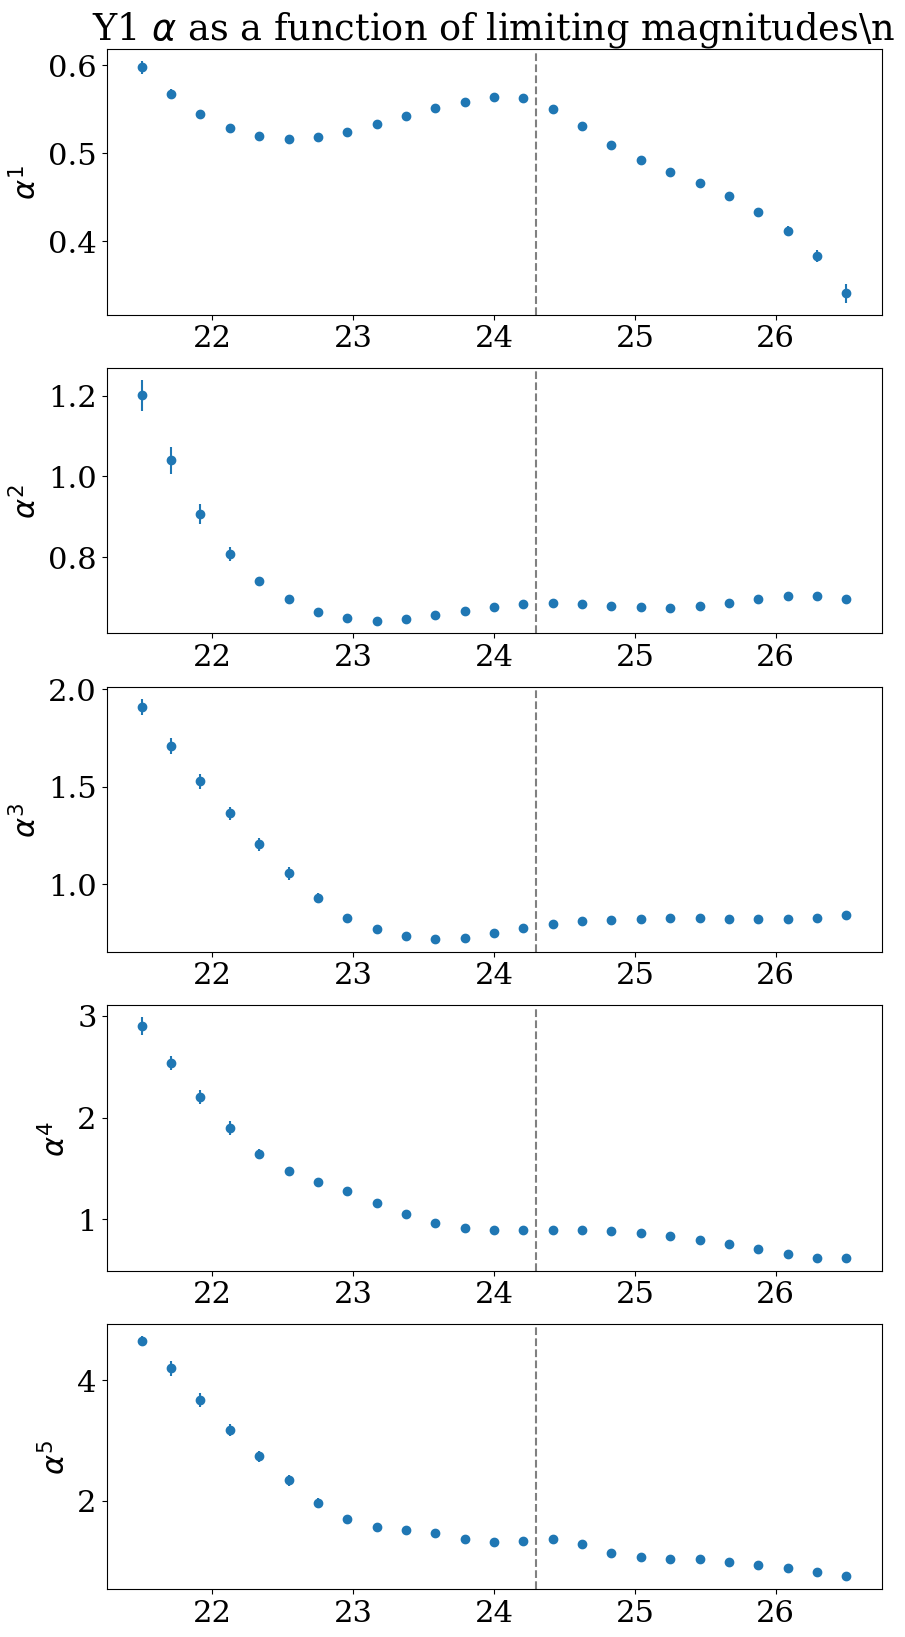

In [6]:
fig, axs = plt.subplots(5, figsize=(10,20))

for i in range(5):
    axs[i].errorbar(maglims, alpha_values_y1[:,i,0], yerr=alpha_values_y1[:,i,1], fmt='o')
    
    axs[i].set_ylabel(rf'$\alpha^{i+1}$')
    axs[i].axvline(24.3, color='gray', linestyle='--')

axs[0].set_title(r"Y1 $\alpha$ as a function of limiting magnitudes\n")

Text(0.5, 1.0, 'Y10 $\\alpha$ as a function of limiting magnitudes')

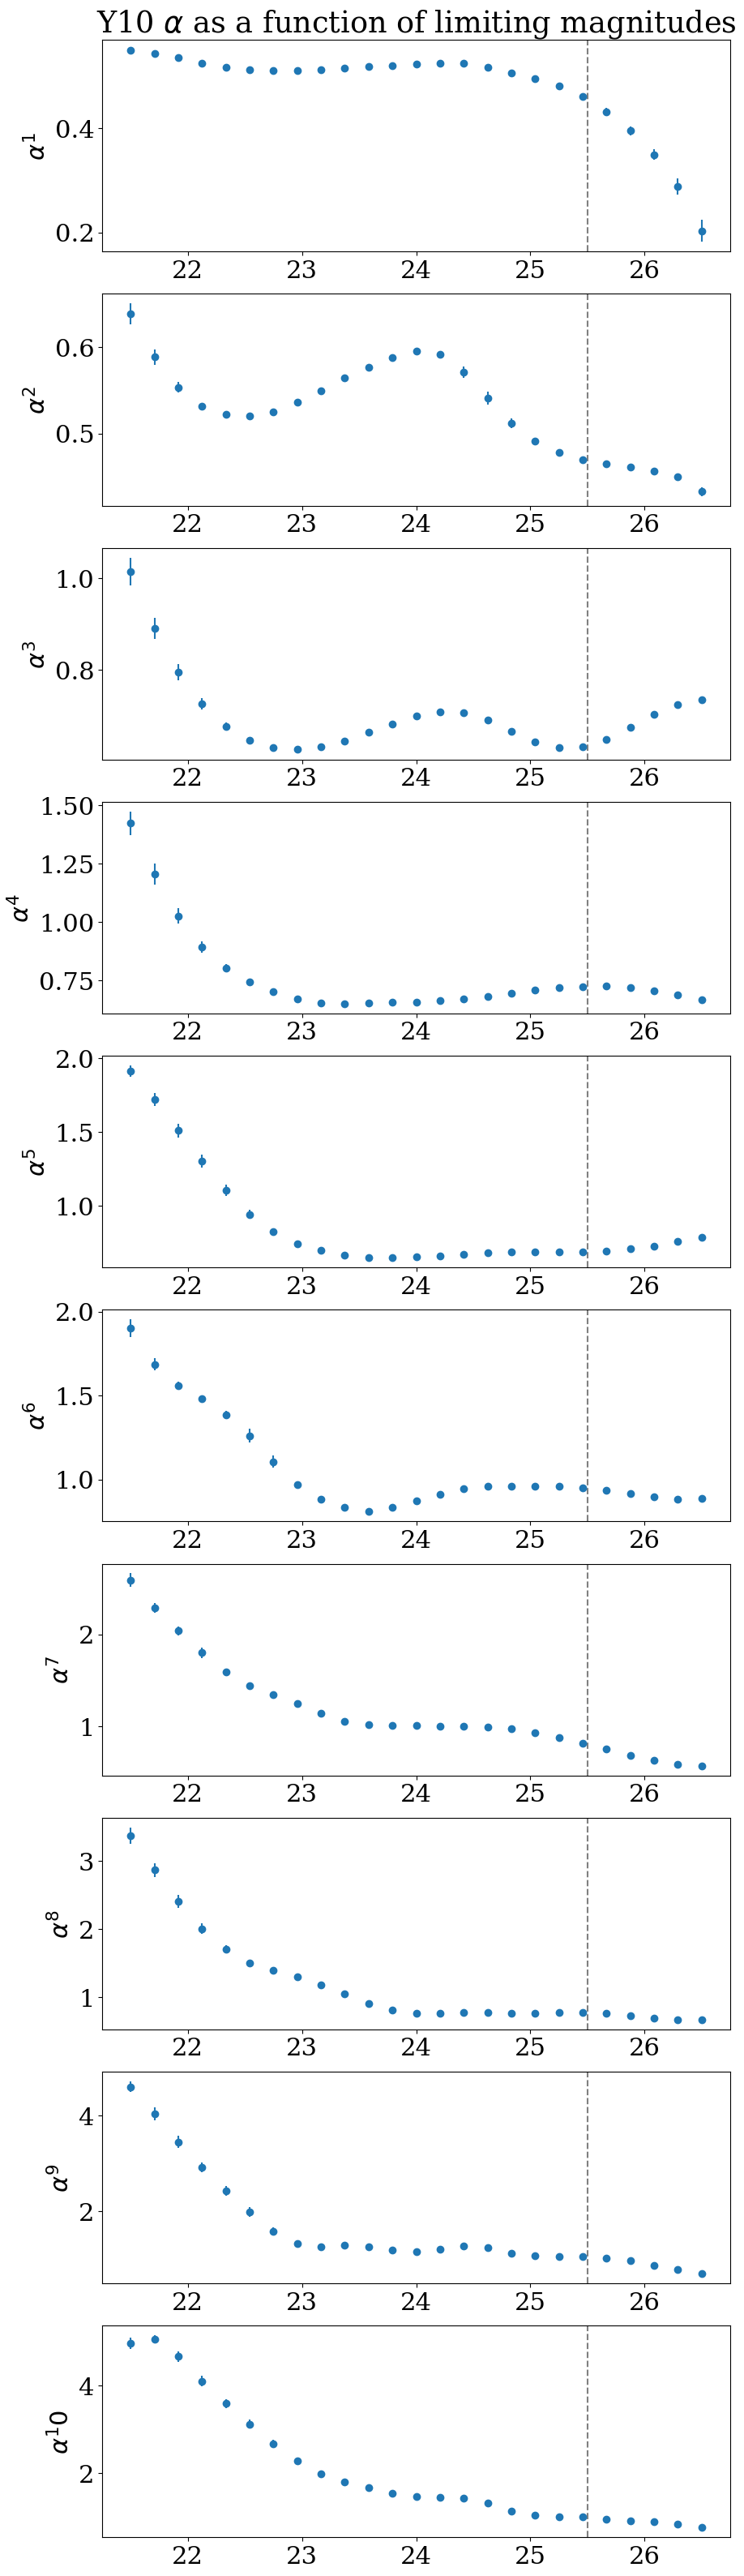

In [7]:
fig, axs = plt.subplots(10, figsize=(10,40))

for i in range(10):
    axs[i].errorbar(maglims, alpha_values_y10[:,i,0], yerr=alpha_values_y10[:,i,1], fmt='o')
    
    axs[i].set_ylabel(rf'$\alpha^{i+1}$')
    axs[i].axvline(25.5, color='gray', linestyle='--')

axs[0].set_title(r"Y10 $\alpha$ as a function of limiting magnitudes")

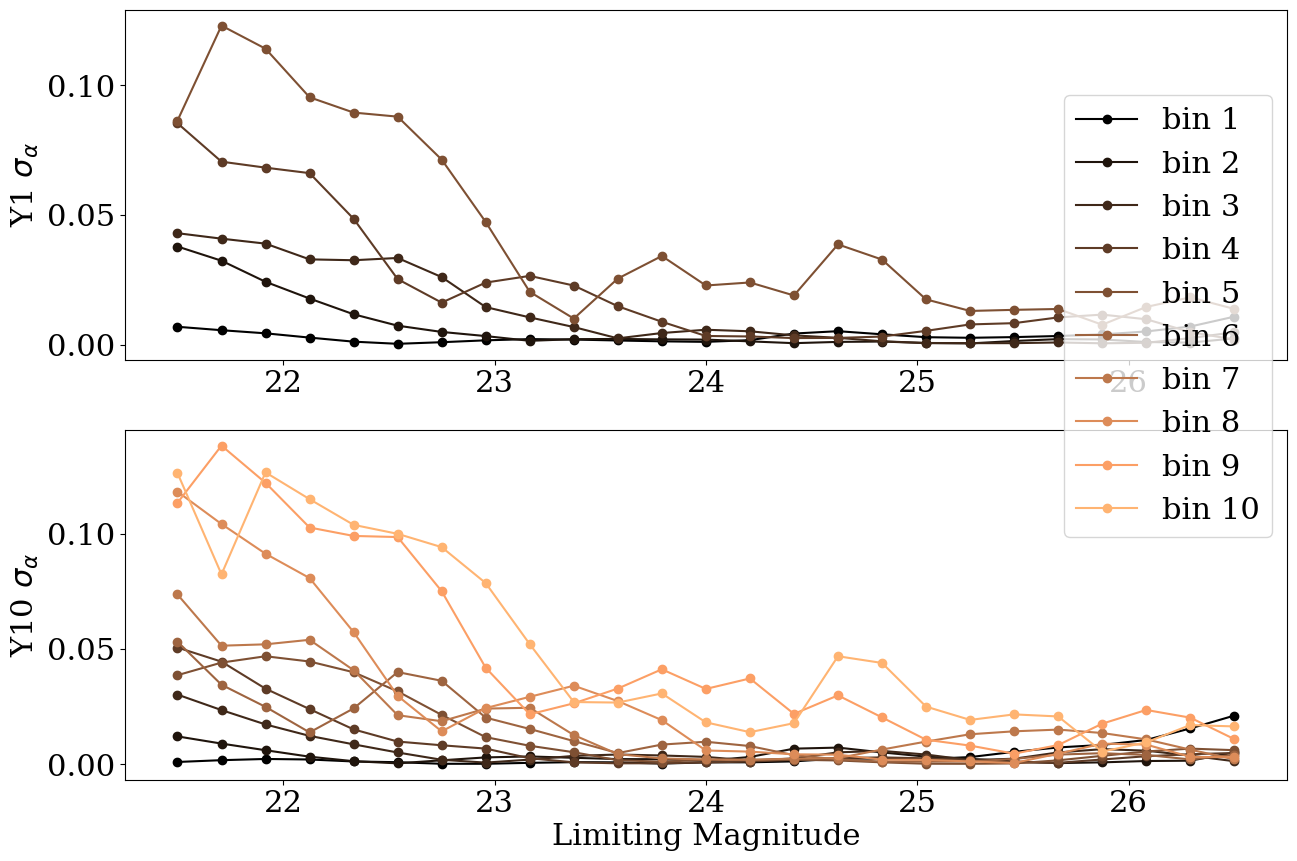

In [8]:
fig, axs = plt.subplots(2, figsize=(15,20))

cmap = plt.get_cmap('copper')
for i in range(10):
    if i < 5:
        axs[0].plot(maglims, alpha_values_y1[:,i,1], 'o-', color=cmap(i/10), label='bin %i'%(i+1))
    axs[1].plot(maglims, alpha_values_y10[:,i,1], 'o-', color=cmap(i/10), label='bin %i'%(i+1))

axs[0].set_ylabel('Y1 '+r'$\sigma_{\alpha}$')
axs[1].set_ylabel('Y10 '+r'$\sigma_{\alpha}$')

axs[1].legend(bbox_to_anchor=(1,2))
plt.gcf().set_size_inches(15,10)
plt.xlabel('Limiting Magnitude')
plt.show()

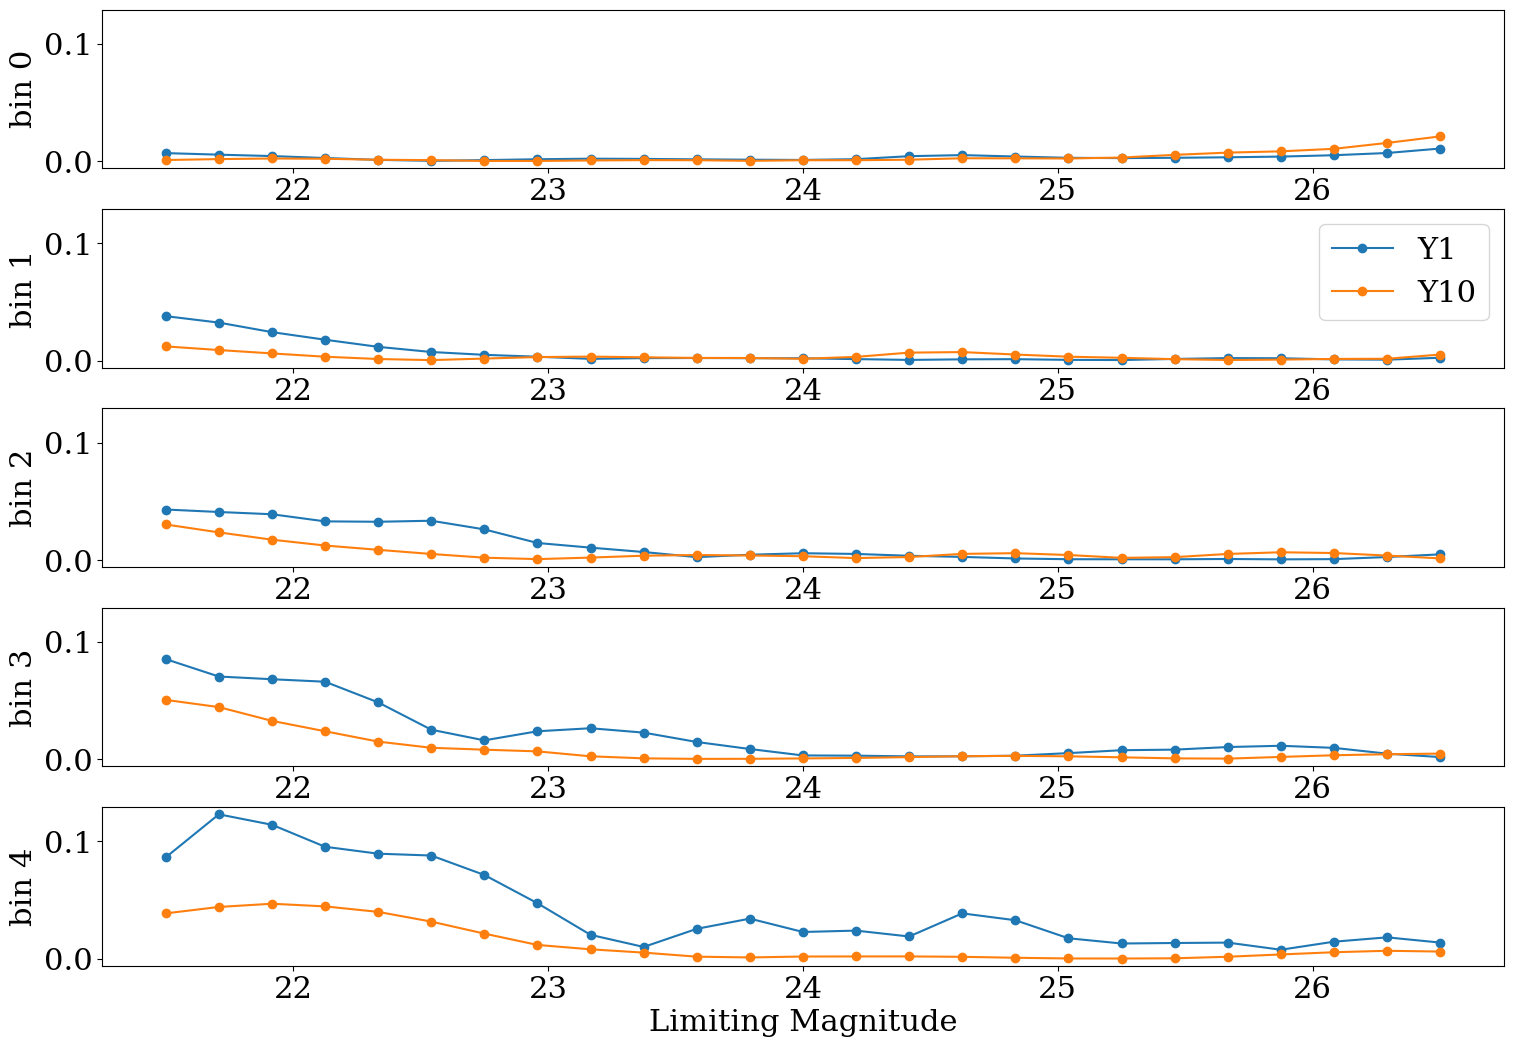

In [9]:
fig, axs = plt.subplots(5, figsize=(15,30), sharey=True)

cmap = plt.get_cmap('copper')
for i in range(5):
    axs[i].plot(maglims, alpha_values_y1[:,i,1], 'o-', label='Y1')
    axs[i].plot(maglims, alpha_values_y10[:,i,1], 'o-', label='Y10')

    axs[i].set_ylabel('bin %i'%i)

axs[1].legend()
fig.set_size_inches(15,10)
fig.tight_layout(pad=0.1)
plt.xlabel('Limiting Magnitude')
plt.show()

In [10]:
bin_midpoints_y1 = np.array([(v0+v1)/2 for v0,v1 in zip(binedges_y1, binedges_y1[1:])])
bin_midpoints_y10 = np.array([(v0+v1)/2 for v0,v1 in zip(binedges_y10, binedges_y10[1:])])

tbl1_vals = np.array([(0.445,0.005), (0.663, 0.006), (0.848, 0.006), (0.781, 0.005), 
                      (0.573, 0.004), (0.694, 0.006), (0.74, 0.01), (0.95, 0.02),
                      (1.39, 0.01), (2.24, 0.02)]
                    )

In [11]:
y10maglim = 26.5 ; y1maglim = 25.3
Y1_idx = np.where(np.abs(maglims-y1maglim) == np.min(np.abs(maglims-y1maglim)))[0][0]
Y10_idx = np.where(np.abs(maglims-y10maglim) == np.min(np.abs(maglims-y10maglim)))[0][0]
Y1_idx, Y10_idx

(18, 24)

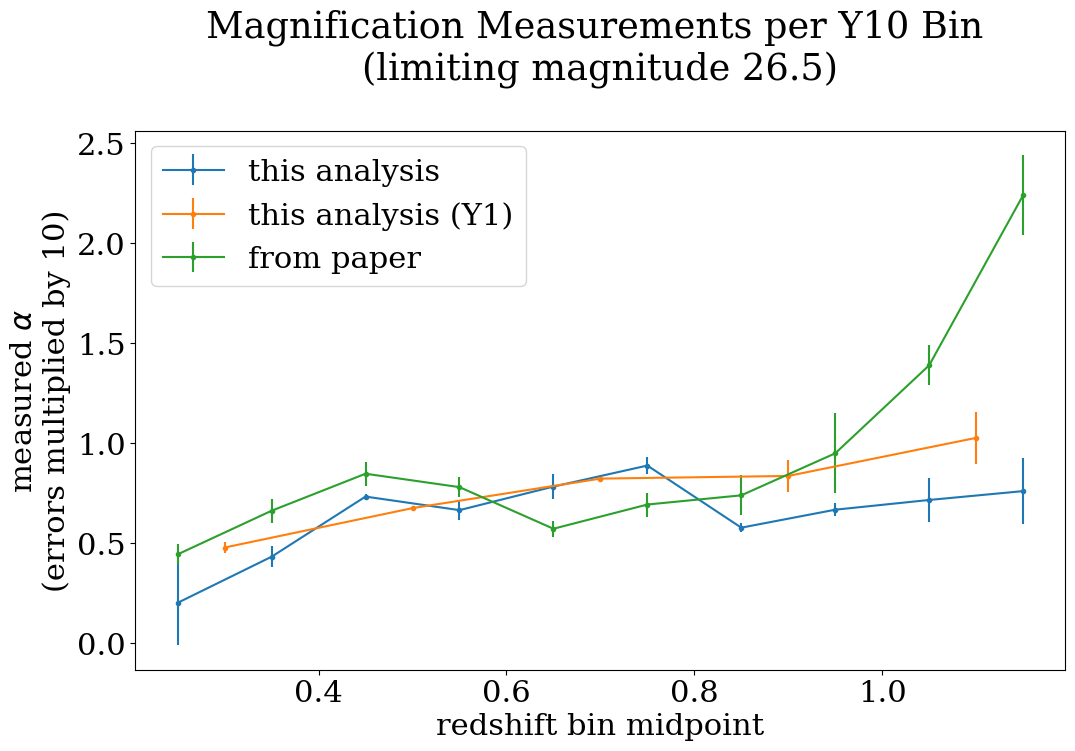

In [12]:
plt.errorbar(bin_midpoints_y10, alpha_values_y10[Y10_idx,:,0], yerr=10*alpha_values_y10[Y10_idx,:,1], fmt='.-',
             label="this analysis")
plt.errorbar(bin_midpoints_y1, alpha_values_y1[Y1_idx,:,0], yerr=10*alpha_values_y1[Y1_idx,:,1], fmt='.-',
             label="this analysis (Y1)")
plt.errorbar(bin_midpoints_y10, tbl1_vals[:,0], yerr=10*tbl1_vals[:,1], fmt='.-', label="from paper")
plt.legend()
plt.gcf().set_size_inches(12,7)
plt.xlabel('redshift bin midpoint')
plt.ylabel(r'measured $\alpha$' + '\n(errors multiplied by 10)')

plt.title("Magnification Measurements per Y10 Bin \n(limiting magnitude %.01f)\n"%y10maglim)
plt.show()

In [20]:
# set Y10 magnitude errors to 0.1, then 0.2 for bins 9 and 10
alpha_values_y10[:9,:,1] = 0.1
alpha_values_y10[9:,:,1] = 0.2

alpha_values_y1[:,:,1] = 0.2

In [22]:
np.save("magbias_forecast_values_y1.npy", alpha_values_y1)
np.save("magbias_forecast_values_y10.npy", alpha_values_y10)
np.save("magbias_maglims.npy", maglims)

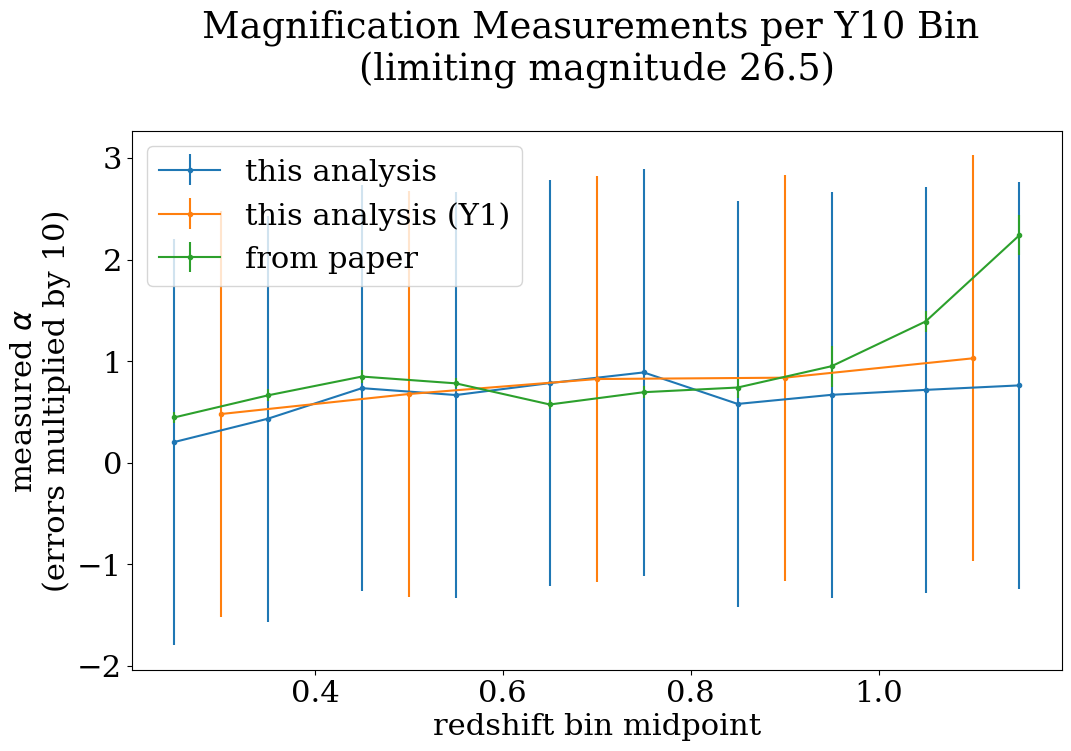

In [23]:
plt.errorbar(bin_midpoints_y10, alpha_values_y10[Y10_idx,:,0], yerr=10*alpha_values_y10[Y10_idx,:,1], fmt='.-',
             label="this analysis")
plt.errorbar(bin_midpoints_y1, alpha_values_y1[Y1_idx,:,0], yerr=10*alpha_values_y1[Y1_idx,:,1], fmt='.-',
             label="this analysis (Y1)")
plt.errorbar(bin_midpoints_y10, tbl1_vals[:,0], yerr=10*tbl1_vals[:,1], fmt='.-', label="from paper")
plt.legend()
plt.gcf().set_size_inches(12,7)
plt.xlabel('redshift bin midpoint')
plt.ylabel(r'measured $\alpha$' + '\n(errors multiplied by 10)')

plt.title("Magnification Measurements per Y10 Bin \n(limiting magnitude %.01f)\n"%y10maglim)
plt.show()